### Validate that cluster.sort() in the analyzer is also sorting arrays for eta and phi, and not just cluster ID.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import uproot

In [2]:
DATA_FILE = '/uscms/home/tlee/nobackup/work/mds-ml/data/MuonSystem_Tree.root'

root_file = uproot.open(DATA_FILE)
tree = root_file['MuonSystem']

csc_phi = tree['CscRechitsPhi'].array(library='np')
csc_eta = tree['CscRechitsEta'].array(library='np')
csc_id = tree['CscRechitsClusterId'].array(library='np')

csc_cluster_phi = tree['cscRechitClusterPhi'].array(library='np')
csc_cluster_eta = tree['cscRechitClusterEta'].array(library='np')

dt_phi = tree['DtRechitsPhi'].array(library='np')
dt_eta = tree['DtRechitsEta'].array(library='np')
dt_id = tree['DtRechitsClusterId'].array(library='np')

dt_cluster_phi = tree['dtRechitClusterPhi'].array(library='np')
dt_cluster_eta = tree['dtRechitClusterEta'].array(library='np')

print("CSC Phi: ")
print(csc_phi)
print("CSC Eta: ")
print(csc_eta)
print("CSC Id: ")
print(csc_id)

print("CSC Cluster Phi: ")
print(csc_cluster_phi)
print("CSC Cluster Eta: ")
print(csc_cluster_eta)

print("DT Phi: ")
print(dt_phi)
print("DT Eta: ")
print(dt_eta)
print("DT Id: ")
print(dt_id)

print("DT Cluster Phi: ")
print(dt_cluster_phi)
print("DT Cluster Eta: ")
print(dt_cluster_eta)



CSC Phi: 
[array([ 2.0553117,  2.055508 ,  2.0559008, ..., -2.488837 , -2.4903355,
        -2.4916103], shape=(1223,), dtype=float32)
 array([-0.7884446 , -0.79144144, -0.7953164 , -0.7988251 , -0.8021657 ,
        -0.8055533 ,  3.0241504 ,  3.0241153 ,  3.0240858 ,  3.0240104 ,
         3.0239508 ,  3.0237753 ,  3.023561  ,  3.014566  ,  3.014535  ,
         3.014509  ,  3.014443  ,  3.0143924 ,  3.0142474 ,  3.0140772 ,
         2.9851294 ,  2.9851394 ,  2.9851482 ,  2.985173  ,  2.9851909 ,
         2.985247  ,  2.9853146 ,  2.9587204 ,  2.9586892 ,  2.9586637 ,
         2.9585977 ,  2.9585478 ,  2.9584029 ,  2.9582324 ,  2.950345  ,
         2.950316  ,  2.950291  ,  2.9502258 ,  2.9501681 ,  2.9499757 ,
         2.9496753 ,  2.950345  ,  2.950316  ,  2.950291  ,  2.9502258 ,
         2.9501681 ,  2.9499757 ,  2.9496753 ,  2.9432478 ,  2.9432583 ,
         2.9432669 ,  2.9432914 ,  2.943309  ,  2.9433641 ,  2.9434304 ,
         2.9078379 ,  2.907803  ,  2.9077744 ,  2.9076996 ,  2.

/tmp/ipykernel_4089097/4285750611.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_csc = cm.get_cmap('tab20', len(unique_csc_ids))
/tmp/ipykernel_4089097/4285750611.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_dt = cm.get_cmap('tab20b', len(unique_dt_ids))


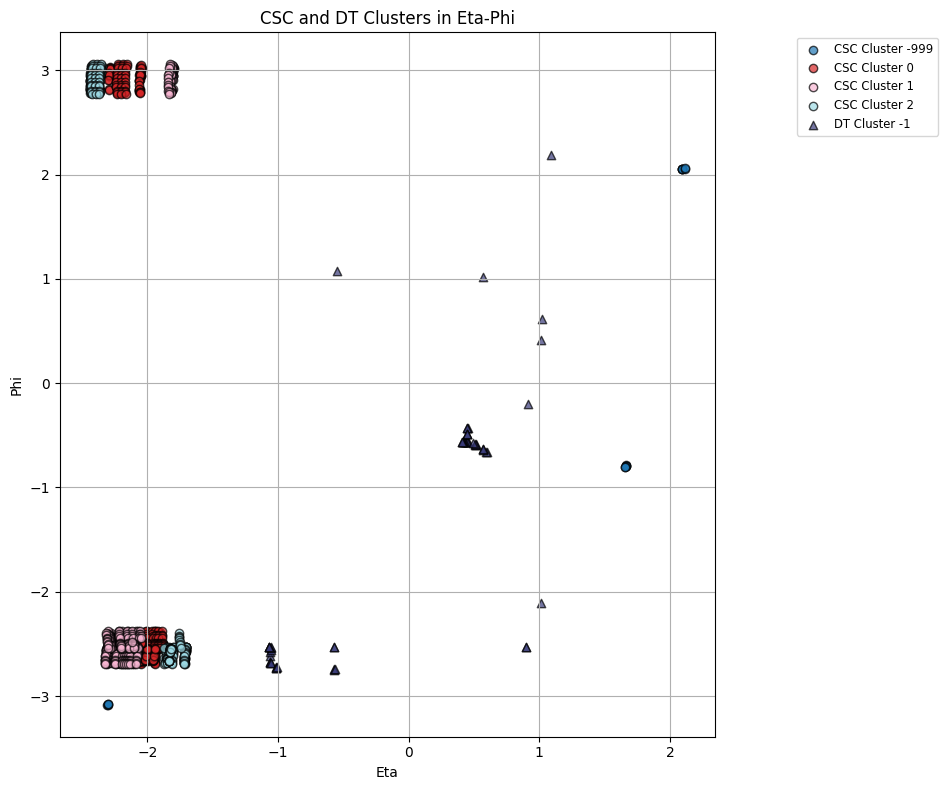

In [3]:
csc_phi = np.concatenate(csc_phi)
csc_eta = np.concatenate(csc_eta)
csc_id = np.concatenate(csc_id)

dt_phi = np.concatenate(dt_phi)
dt_eta = np.concatenate(dt_eta)
dt_id = np.concatenate(dt_id)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# CSC cluster plot
unique_csc_ids = np.unique(csc_id)
cmap_csc = cm.get_cmap('tab20', len(unique_csc_ids))
for i, cid in enumerate(unique_csc_ids):
    mask = csc_id == cid
    ax.scatter(csc_eta[mask], csc_phi[mask], label=f'CSC Cluster {cid}', c=[cmap_csc(i)], marker='o', edgecolors='k', alpha=0.7)

# DT cluster plot
unique_dt_ids = np.unique(dt_id)
cmap_dt = cm.get_cmap('tab20b', len(unique_dt_ids))
for i, did in enumerate(unique_dt_ids):
    mask = dt_id == did
    ax.scatter(dt_eta[mask], dt_phi[mask], label=f'DT Cluster {did}', c=[cmap_dt(i)], marker='^', edgecolors='k', alpha=0.7)

ax.set_xlabel('Eta')
ax.set_ylabel('Phi')
ax.set_title('CSC and DT Clusters in Eta-Phi')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0), fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()
